## Chuẩn bị dữ liệu

In [ ]:
%load_ext autoreload
%autoreload 2

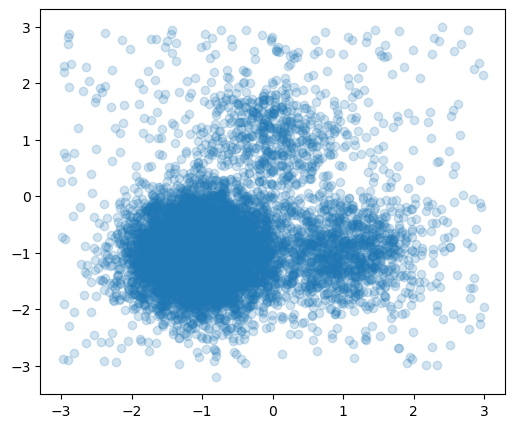

Dữ liệu đã sẵn sàng: (9000, 2)


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))

from src.utils import generate_simulated_data

# Khởi tạo dữ liệu
X = generate_simulated_data(random_state=42)

figh, figw = 1, 1
fig, ax = plt.subplots(figh, figw, figsize=(6 * figw, 5))
ax.scatter(X[:, 0], X[:, 1], alpha=0.2)
plt.show()
print(f"Dữ liệu đã sẵn sàng: {X.shape}")

In [ ]:
from src.model import hierarchical_kmeans_resampling, kmeans_with_power_s_stable
from src.metrics import calculate_kl_divergence
from sklearn.cluster import KMeans
import pandas as pd 
import numpy as np

kl_results = {}
all_centroids = {}

# Tính KL cho dữ liệu gốc
kl_results['data'] = calculate_kl_divergence(X)

d:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [ ]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import pairwise_distances

# --- 1. DBSCAN CHUẨN TÁC GIẢ ---
print("Đang chạy DBSCAN (chuẩn Elbow method)...")
min_points = 5
# Tính khoảng cách k-NN để tìm eps
pw_distance = pairwise_distances(X)
pw_distance = np.sort(pw_distance, axis=1)
nn_dist = pw_distance[:, min_points]
sorted_nn_dist = np.sort(nn_dist)[::-1]

# Epsilon theo đúng elbow của tác giả (vị trí 1000)
eps_elbow = sorted_nn_dist[1000]

db = DBSCAN(eps=eps_elbow, min_samples=min_points).fit(X)

db_clusters = [np.where(db.labels_ == i)[0] for i in range(db.labels_.max() + 1)]
db_centroids = np.array([X[db_clusters[i]].mean(axis=0) for i in range(len(db_clusters))])

all_centroids['dbscan'] = db_centroids


# AGGLOMERATIVE
print("Đang chạy Agglomerative Clustering...")
ac = AgglomerativeClustering(n_clusters=300)
ac.fit(X)

ac_clusters = [np.where(ac.labels_ == i)[0] for i in range(ac.labels_.max() + 1)]
ac_centroids = np.array([X[ac_clusters[i]].mean(axis=0) for i in range(len(ac_clusters))])

all_centroids['agglomerative'] = ac_centroids

# 3. Standard K-means (s=2)
km = KMeans(n_clusters=300, random_state=42).fit(X)
all_centroids['k-means'] = km.cluster_centers_

# Tính KL 
for name in ['dbscan', 'agglomerative', 'k-means']:
    kl_results[name] = calculate_kl_divergence(all_centroids[name])

Đang chạy DBSCAN (chuẩn Elbow method)...
Đang chạy Agglomerative Clustering...


In [ ]:
from src.model import kmeans_with_power_s_stable
from src.metrics import calculate_kl_divergence 

print("--- Bắt đầu chạy K-means với power s ---")

for s in [4, 64, 256]:
    name = f'k-means, s={s}'
    print(f"Đang tính toán cho {name}...")
    
    centroids = kmeans_with_power_s_stable(X, k=300, s_target=s, n_iters=20)
    all_centroids[name] = centroids
    
    kl_val = calculate_kl_divergence(centroids, L=3, step=0.02, bandwidth=0.5)
    kl_results[name] = kl_val
    
    print(f"   => Hoàn thành {name}: KL = {kl_val:.4f}")

--- Bắt đầu chạy K-means với power s ---
Đang tính toán cho k-means, s=4...
   => Hoàn thành k-means, s=4: KL = 0.3269
Đang tính toán cho k-means, s=64...
   => Hoàn thành k-means, s=64: KL = 0.1329
Đang tính toán cho k-means, s=256...
   => Hoàn thành k-means, s=256: KL = 0.1157


In [ ]:
print("Đang chạy Hierarchical K-means...")

# 1. Ours 2-level (No resampling)
all_centroids['ours, 2-level'] = hierarchical_kmeans_resampling(X, [1500, 300], 2, 0, 0, num_init=10)

# 2. Ours 3-level (No resampling)
all_centroids['ours, 3-level'] = hierarchical_kmeans_resampling(X, [3000, 1000, 300], 3, 0, 0, num_init=10)

# 3. Ours 3-level w/ resampling
all_centroids['ours, 3-level w/ resamp.'] = hierarchical_kmeans_resampling(
    X, 
    k_list=[3000, 1000, 300], 
    T=3, 
    m=10, 
    r_t_list=[2, 2, 2], 
    num_init=1
)

for name in ['ours, 2-level', 'ours, 3-level', 'ours, 3-level w/ resamp.']:
    kl_results[name] = calculate_kl_divergence(all_centroids[name], L=3, step=0.02, bandwidth=0.5)

Đang chạy Hierarchical K-means...
--- Level 1/2 (k=1500, r_t=0) ---
--- Level 2/2 (k=300, r_t=0) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


--- Level 1/3 (k=3000, r_t=0) ---
--- Level 2/3 (k=1000, r_t=0) ---
--- Level 3/3 (k=300, r_t=0) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


--- Level 1/3 (k=3000, r_t=2) ---
--- Level 2/3 (k=1000, r_t=2) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 3/3 (k=300, r_t=2) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

In [ ]:
lb_vals = []
for _ in range(10):
    rp = np.random.uniform(-3, 3, (300, 2))
    lb_vals.append(calculate_kl_divergence(rp, L=3, step=0.02, bandwidth=0.5))
lower_bound = np.mean(lb_vals)
print(f"Lower bound (random points): KL ≈ {lower_bound:.4f}")

Lower bound (random points): KL ≈ 0.0392


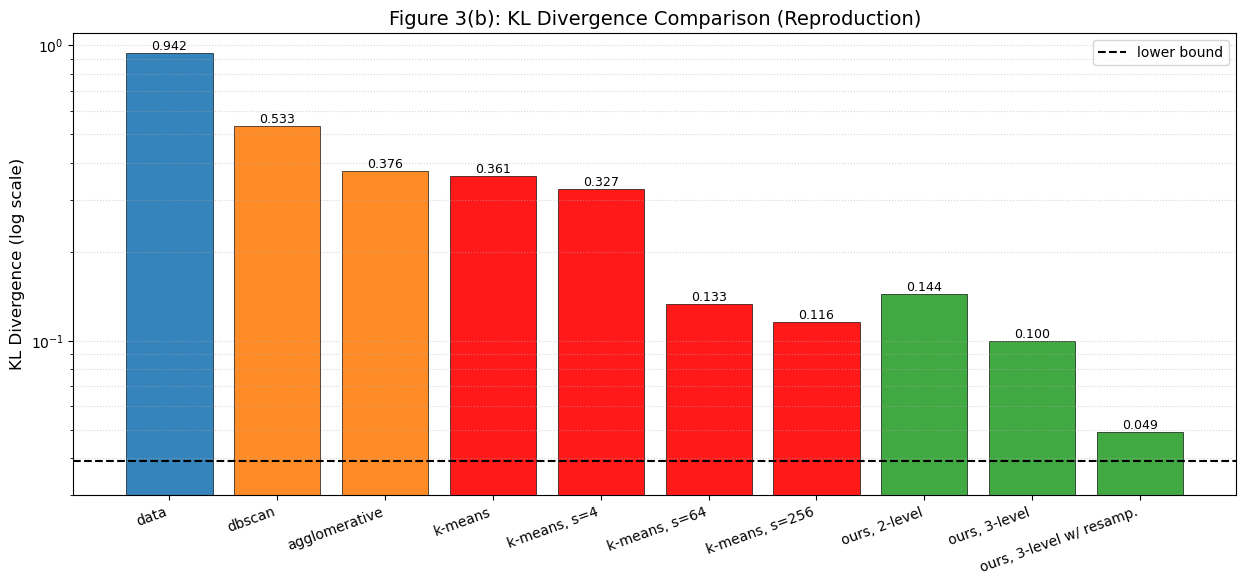

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = [
    'data', 'dbscan', 'agglomerative', 'k-means', 
    'k-means, s=4', 'k-means, s=64', 'k-means, s=256', 
    'ours, 2-level', 'ours, 3-level', 'ours, 3-level w/ resamp.'
]

values = [kl_results.get(cat, 1e-10) if kl_results.get(cat) is not None else 1e-10 for cat in categories]

colors = ['tab:blue', 'tab:orange', 'tab:orange', 'red', 'red', 'red', 'red', 'tab:green', 'tab:green', 'tab:green']

plt.figure(figsize=(15, 6))

bars = plt.bar(categories, values, color=colors, alpha=0.9, edgecolor='black', linewidth=0.5)

# Vẽ đường Lower Bound
plt.axhline(y=lower_bound, color='black', linestyle='--', label='lower bound')

plt.yscale('log') 
plt.ylabel('KL Divergence (log scale)', fontsize=12)
plt.title('Figure 3(b): KL Divergence Comparison (Reproduction)', fontsize=14)
plt.xticks(rotation=20, ha='right')

plt.ylim(bottom=max(1e-3, min(values)*0.5)) 

plt.grid(axis='y', which='both', linestyle=':', alpha=0.5)
plt.legend()

for bar in bars:
    yval = bar.get_height()
    if yval > 1e-10: 
        plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', 
                 va='bottom', ha='center', fontsize=9)

plt.yscale('log')
plt.ylim(0.03, 1.1)


plt.show()

d:\Data Mining\Data-Mining-Lab-3-Clustering-and-its-applications\src\visualization.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


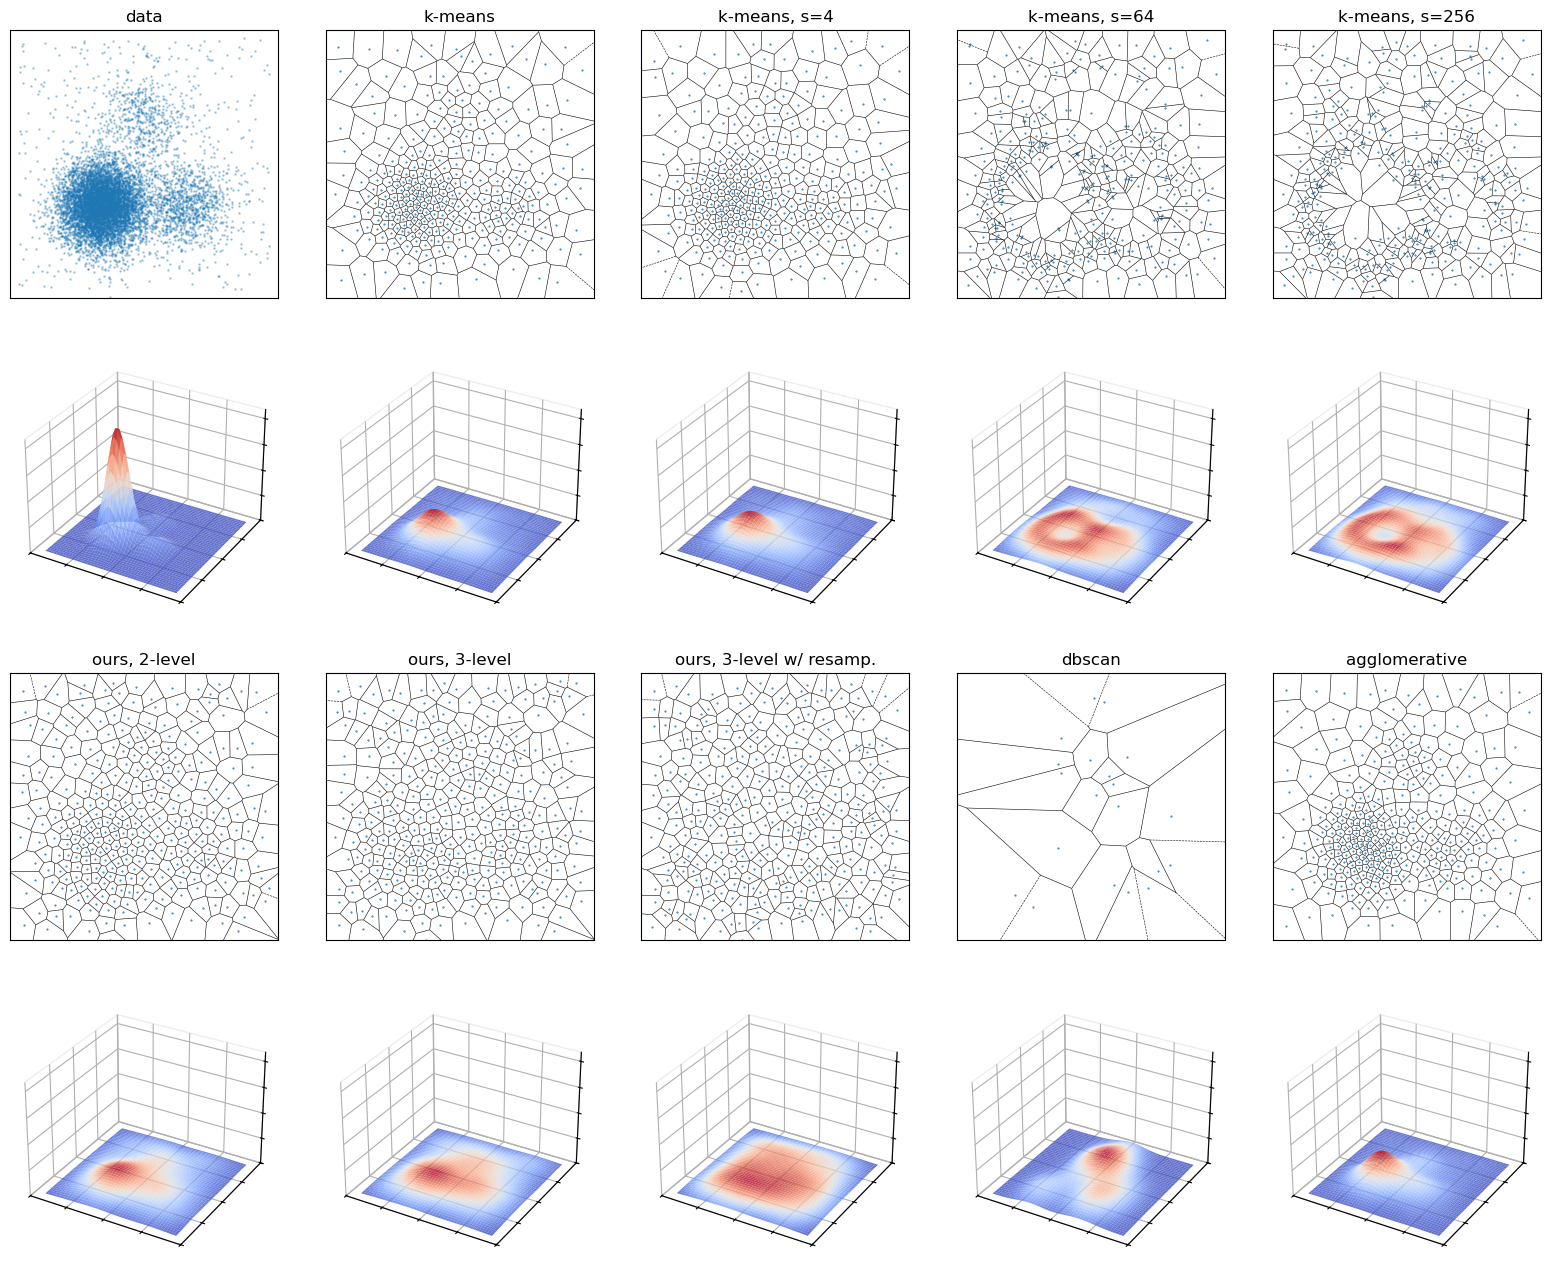

In [ ]:
from src.visualization import plot_paper_style_fig3a

# Thực thi
plot_paper_style_fig3a(X, all_centroids)